In [9]:


import numpy as np

import pylab as pl
pl.rcParams['figure.figsize'] = 12, 16

import healpy as hp

import pdb
from astropy.table import Table
import pandas as pd

import fgbuster.separation_recipes as sr
# Imports needed for component separation
from fgbuster import (   Synchrotron, FreeFree,AnalyticComponent,  Component , # sky-fitting model
                      MixingMatrix)  # separation routine
import warnings
warnings.filterwarnings("ignore")
import argparse
import os
from astropy.io import fits
from  matplotlib import pyplot as plt
import time




class FreeFree(AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -2.14
    _REF_F = -3  
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None,
                 units='K_CMB'):
        

        # Prepare the analytic expression
        analytic_expr = ('(nu / nu0)**beta_pl  ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0,  
                  'beta_pl': beta_pl   }

        super(FreeFree, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA ,    )


class  LogSynchrotron (AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    nu_pivot: float
        Pivot frequency for the running
    running: float
        Curvature of the power law
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -3
    _REF_RUN = 0.
    _REF_NU_PIVOT = 70.
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None, nu_pivot=None, running=0.,
                 units='K_CMB'):
        if nu_pivot == running == None:
            print('Warning: are you sure you want both nu_pivot and the running'
                  'to be free parameters?')

        # Prepare the analytic expression
        analytic_expr = ('log(nu / nu0)* ( (beta_pl)  + running * log (nu/nu_pivot) ) ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0, 'nu_pivot': nu_pivot,
                  'beta_pl': beta_pl, 'running': running}

        super(LogSynchrotron, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA, running=self._REF_RUN, nu_pivot=self._REF_NU_PIVOT)




In [44]:

hdul = fits.open("../inputmaps/coarse_north_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float_(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load("../inputmaps/coarse_north_errors_dict.npz")
errv = [v for v in mapserr_table.values() ] 

#df['depth_i']= errv 
df['depth_i']= errv 
instrument = df.dropna(axis=1, how='all')
hdul.close()

nu0 = 0.045
idmap =  np.argmin(np.fabs(df['frequency'] - nu0 ))



In [45]:
freq_maps=hp.read_map("../inputmaps/coarse_north_maps_nside256.fits",  field=cols  )
nside_new = 64 
noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )

j=0
freq_maps_ud=[]
for i  in range(nfreq ):
   
    mask =np.isnan(freq_maps[i] )
    freq_maps[i][mask]=hp.UNSEEN 

    freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    #hp.mollview(   freq_maps_ud[i ]     , 
    #             title=f'{cols[i] } MHz'  , 
    #            sub=(5,4,1+j) , notext=True)
    j+=1

freq_maps=np.vstack(freq_maps_ud)
freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])

instrument ['depth_i'] = instrument ['depth_i'] / noise_factor


In [46]:
instrument 


,frequency,depth_i
0,0.045,75.0
1,0.050,13.862232
2,0.060,8.98716
3,0.070,6.369171
4,0.074,5.339192
5,0.080,4.606345
6,0.159,0.125
7,0.408,0.025
8,1.383,0.01025
9,1.418,0.01025


In [47]:


nside = 32
options={'disp':False , 'gtol': 1e-18, 'eps': 1e-18,   'maxiter': 1000, 'ftol': 1e-18 }
tol = 1e-18
method='TNC'
components =[  Synchrotron(nu0=0.408, running=None   ,  units='K_RJ'  ) , 
                  FreeFree(nu0=2. ,  units='K_RJ'  )
                    ]

print(components[0].n_param, components[1].n_param , hp.get_nside(freq_maps[0,:,:]) )
nsidepatches = [nside, 4, nside,nside  ]




#np.savez(f'{args.output_dir}/fgbuster_params_{args.label}_nside{args.nside}.npz',
#                    **{n: a for n, a in zip(results.params, results.x)})



3 1 64


In [48]:


nu0 = df['frequency'][idmap]
 

pl.plot(df['frequency']  , components[0].eval(df['frequency'] , -3,     )/components[0].eval(.405 , -3,     ) ,'.' ) 
print( components[1].n_param )
pl.plot(df['frequency'] , components[1].eval(df['frequency'] ,-2.15   )/components[1].eval(2.2  ,-2.15   ) ,'.' ) 
pl.loglog() 


AssertionError: 

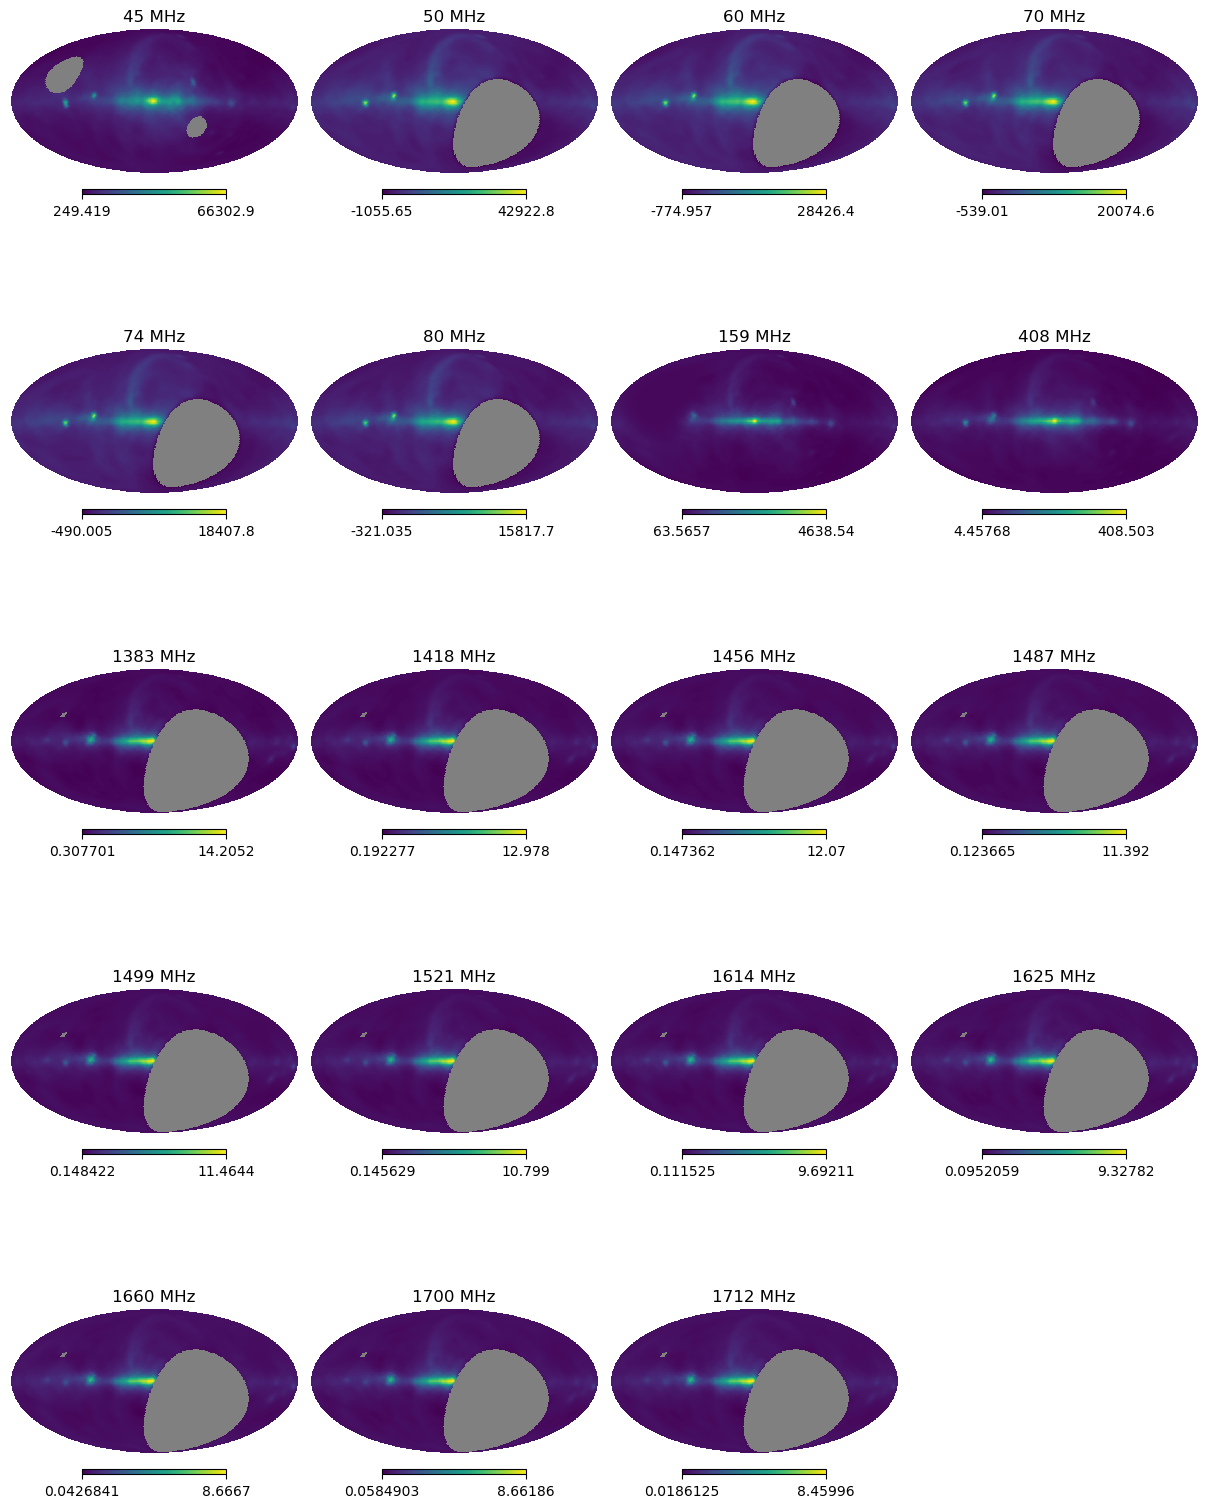

In [49]:

for i  in range(nfreq ):
   
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(5,4,1+i) , notext=True)

In [50]:

#results   = sr.multi_res_comp_sep(components, instrument, freq_maps, nsides= nsidepatches ,
#                                    method=method,tol = tol,
#                                     options=options,
                                    #bounds=bounds,                                    )


results   = sr.multi_res_comp_sep(components, instrument, freq_maps,  
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )

SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> l

In [51]:
(results.chi.shape, freq_maps.shape , results.invAtNA.shape )


((19, 1, 49152), (19, 1, 49152), (49152, 1, 2, 2))

In [52]:
results.invAtNA[:,0,0,0].shape

(49152,)

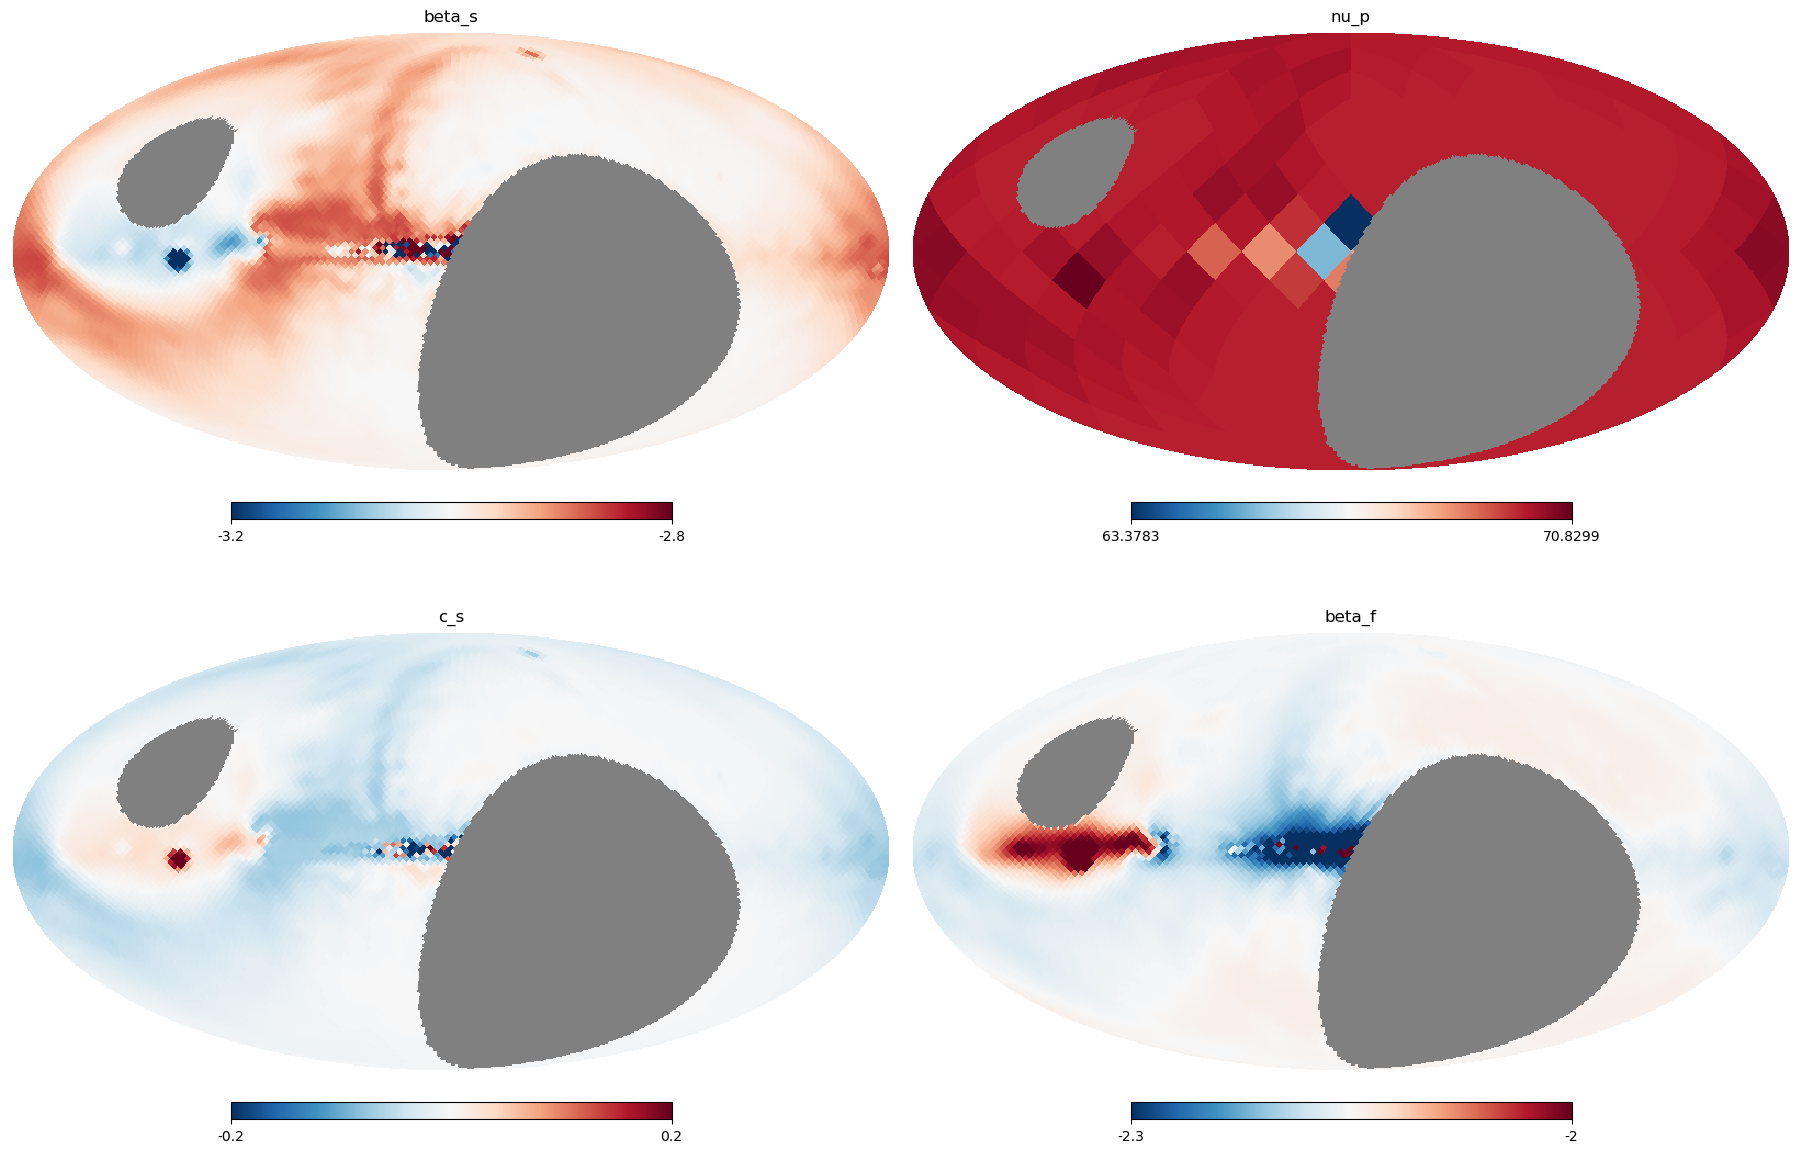

In [74]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)

